# Assignment-II: Data Wrangling-II

## Objective

### To create and clean an Academic Performance dataset by:

- Handling missing values and inconsistencies
- Detecting and treating outliers
- Applying suitable data transformations
- Properly documenting the reasoning behind each step

## Import Required Libraries and Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Data Inspection

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Observation:
- Dataset contains 1000 records
- No structural issues in datatypes
- Numeric variables:
    - `math score`
    - `reading score`
    - `writing score`
- Categorical variables:
    - gender, race/ethnicity, parental level of education, lunch, test preparation course

## Missing Values & Inconsistencies
### Check for Missing Values

In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### Result

No missing values detected

**Reasoning:**
Since the dataset has no missing values, no imputation was required. This ensures no information loss or bias introduction.

### Check for Inconsistencies

In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
for col in df.select_dtypes(include="object"):
    print(col, ":", df[col].unique())

gender : ['female' 'male']
race/ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch : ['standard' 'free/reduced']
test preparation course : ['none' 'completed']


### Result
- Categorical values are consistent
- No spelling or formatting anomalies

## Outlier Detection
### Boxplots for Numerical Variables

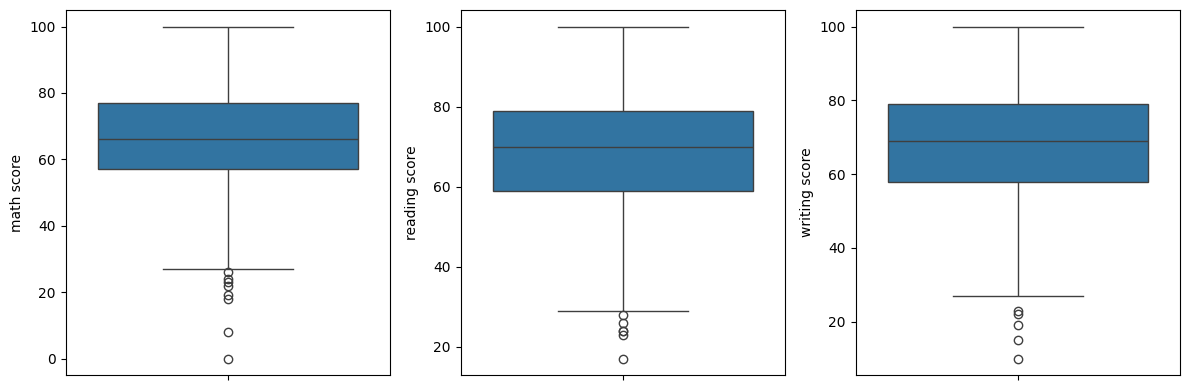

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=df["math score"])

plt.subplot(1,3,2)
sns.boxplot(y=df["reading score"])

plt.subplot(1,3,3)
sns.boxplot(y=df["writing score"])

plt.tight_layout()
plt.show()

**Observation**
- Minor outliers present near lower score ranges
- Scores are valid academic values (0–100)

### IQR-Based Outlier Detection

In [11]:
def detect_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return col[(col < lower) | (col > upper)]

for score in ["math score", "reading score", "writing score"]:
    print(score, "outliers:", len(detect_outliers(df[score])))

math score outliers: 8
reading score outliers: 6
writing score outliers: 5


**Treatment Decision**

Outliers were retained because:
- Scores are realistic exam results
- Removing them may distort academic performance analysis

## Data Transformation
### Create Average Score Feature

In [12]:
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


### Check Distribution

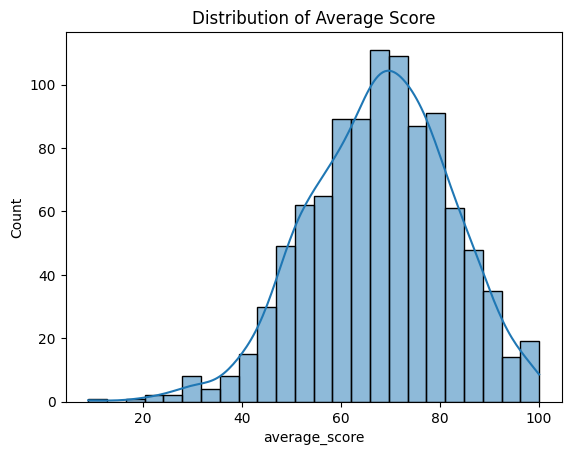

In [13]:
sns.histplot(df["average_score"], kde=True)
plt.title("Distribution of Average Score")
plt.show()

### Apply Log Transformation (Skewness Reduction)

In [15]:
df["log_avg_score"] = np.log1p(df["average_score"])

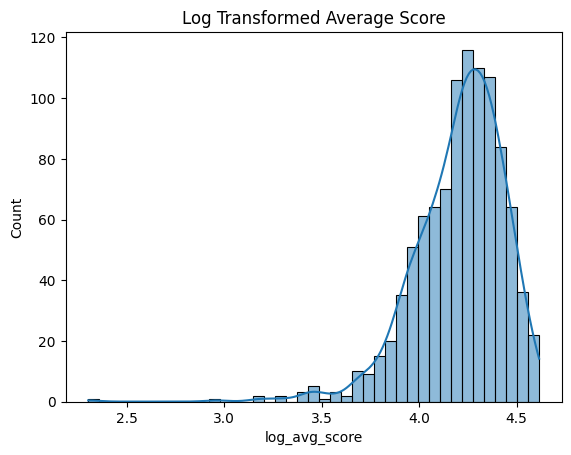

In [16]:
sns.histplot(df["log_avg_score"], kde=True)
plt.title("Log Transformed Average Score")
plt.show()

**Result**
- Distribution is closer to normal
- Suitable for regression and statistical modeling

In [17]:
df.describe()

,math score,reading score,writing score,average_score,log_avg_score
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667,4.206127
std,15.16308,14.600192,15.195657,14.257326,0.233343
min,0.00000,17.000000,10.000000,9.000000,2.302585
25%,57.00000,59.000000,57.750000,58.333333,4.083171
50%,66.00000,70.000000,69.000000,68.333333,4.238926
75%,77.00000,79.000000,79.000000,77.666667,4.365220
max,100.00000,100.000000,100.000000,100.000000,4.615121


In [18]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,log_avg_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,4.299550
1,female,group C,some college,standard,completed,69,90,88,82.333333,4.422849
2,female,group B,master's degree,standard,none,90,95,93,92.666667,4.539742
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,3.918668
4,male,group C,some college,standard,none,76,78,75,76.333333,4.348125
